--- Training Stability Voting ---
Stability Voting Accuracy: 94.87%
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.88      1.00      0.93         7
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         7
           4       0.91      0.91      0.91        11

    accuracy                           0.95        39
   macro avg       0.96      0.95      0.95        39
weighted avg       0.95      0.95      0.95        39

--- Training De-Noising (PCA+LR) ---
De-Noising (PCA+LR) Accuracy: 94.87%
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.88      1.00      0.93         7
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         7
           4       0.91      0.91      0.91        11

    accuracy                           0.95

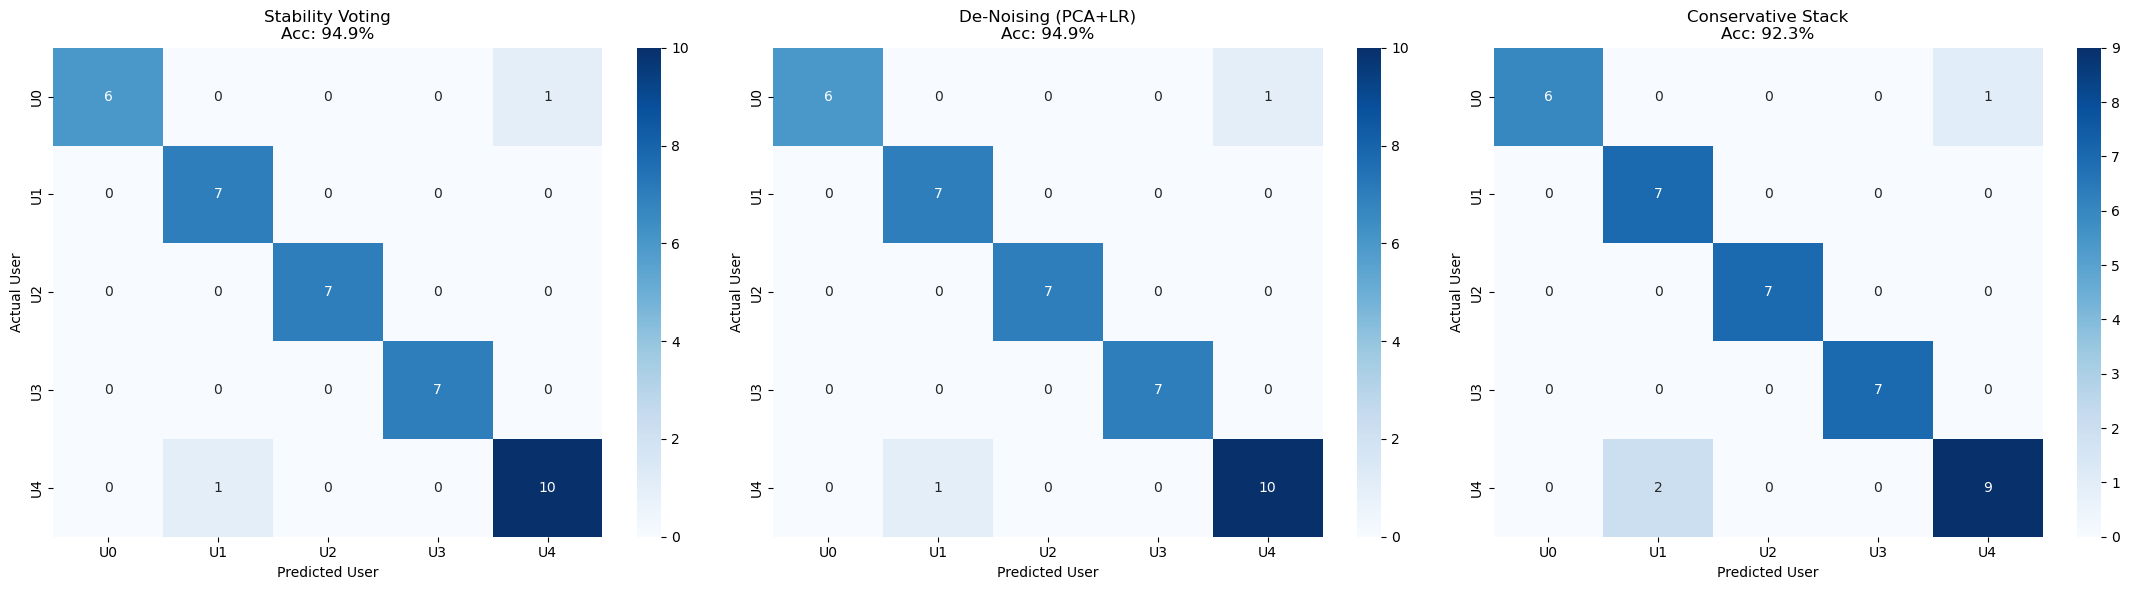

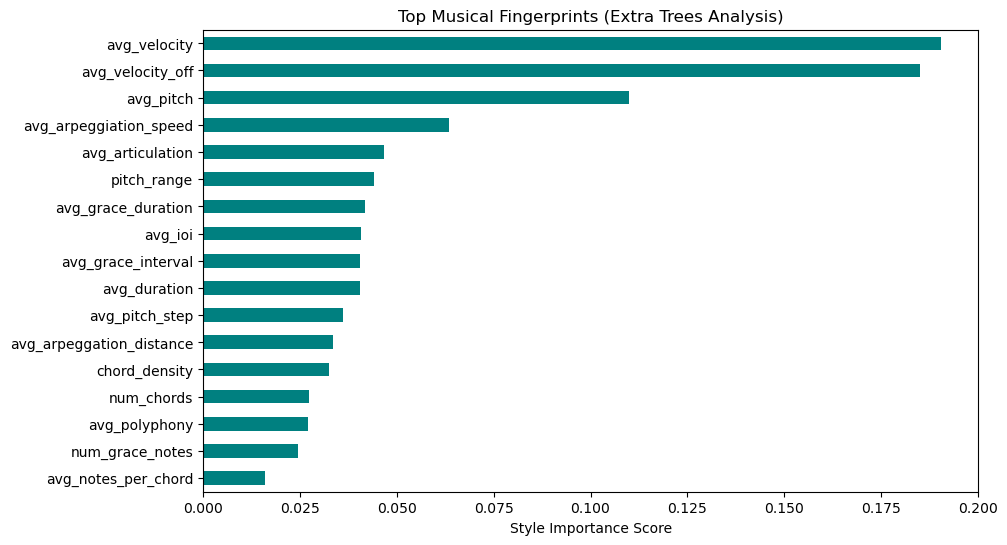


--- Final Performance Comparison ---
                 Model  Accuracy     Trustworthiness
0     Stability Voting  0.948718      High (Diverse)
1  De-Noising (PCA+LR)  0.948718  Highest (Filtered)
2   Conservative Stack  0.923077  Moderate (Complex)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model & Utility imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD DATA
df = pd.read_csv('stacked_dataset.csv')

# 2. PREPARE FEATURES (X) AND TARGET (y)
# Drop metadata to prevent "cheating" and ensure behavioral learning
X = df.drop(columns=['userID', 'window_id', 'time_ms'])
y = df['userID']

# 80-20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. DEFINE THE 3 COMPOUND MODELS

# Model A: Stability Voting Ensemble (Diverse points of view)
stability_voting = VotingClassifier(
    estimators=[
        ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
        ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))),
        ('lr', make_pipeline(StandardScaler(), LogisticRegression(random_state=42)))
    ],
    voting='soft'
)

# Model B: De-Noising Pipeline (PCA + Linear separation)
# This is the most "honest" model; it filters out noise before looking for patterns.
denoising_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)), # Keep 90% of variance
    ('lr', LogisticRegression(random_state=42))
])

# Model C: Conservative Stack (Layered decision making)
conservative_stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)))
    ],
    final_estimator=LogisticRegression(), # Simple meta-model to prevent overfitting
    cv=5
)

# 4. EXECUTE AND COMPARE
models = {
    "Stability Voting": stability_voting,
    "De-Noising (PCA+LR)": denoising_pipeline,
    "Conservative Stack": conservative_stack
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, (name, model) in enumerate(models.items()):
    print(f"--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    # Metrics
    print(f"{name} Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=[f'U{j}' for j in np.unique(y)],
                yticklabels=[f'U{j}' for j in np.unique(y)])
    axes[i].set_title(f'{name}\nAcc: {acc*100:.1f}%')
    axes[i].set_ylabel('Actual User')
    axes[i].set_xlabel('Predicted User')

plt.tight_layout()
plt.show()

# 5. FINAL SANITY CHECK: Feature Importance
# We use Extra Trees (part of the Voting model) to verify musical fingerprints
et_check = ExtraTreesClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
importances = pd.Series(et_check.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Top Musical Fingerprints (Extra Trees Analysis)')
plt.xlabel('Style Importance Score')
plt.show()

# 6. SUMMARY TABLE
print("\n--- Final Performance Comparison ---")
summary_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
summary_df['Trustworthiness'] = ["High (Diverse)", "Highest (Filtered)", "Moderate (Complex)"]
print(summary_df.sort_values(by='Accuracy', ascending=False))


 SCENARIO: 90/10 TRAIN/TEST SPLIT
Training Stability Voting...
Training De-Noising (PCA+LR)...
Training Conservative Stack...


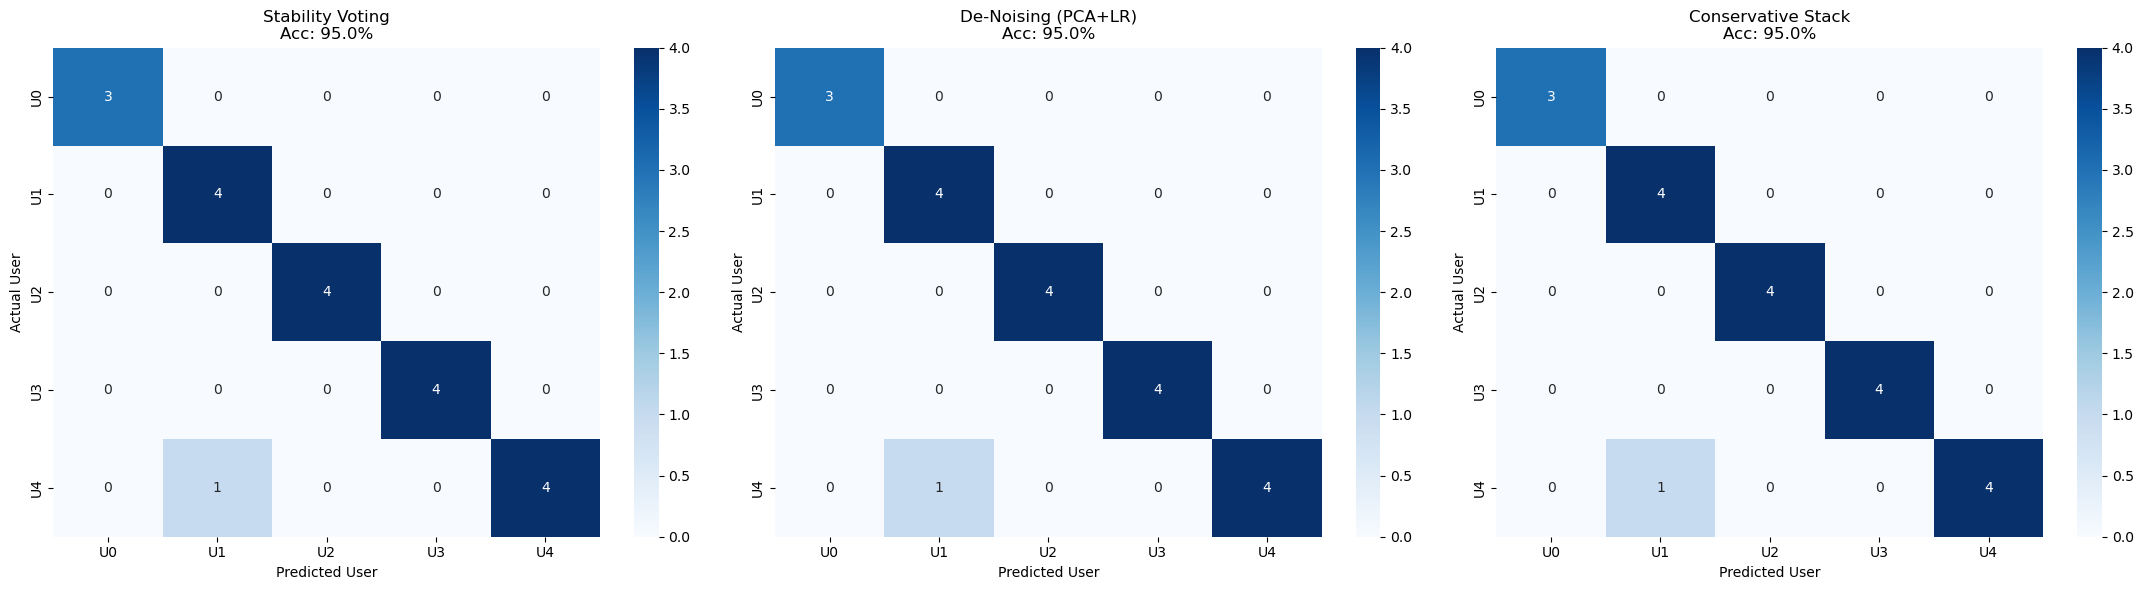


 SCENARIO: 60/40 TRAIN/TEST SPLIT
Training Stability Voting...
Training De-Noising (PCA+LR)...
Training Conservative Stack...


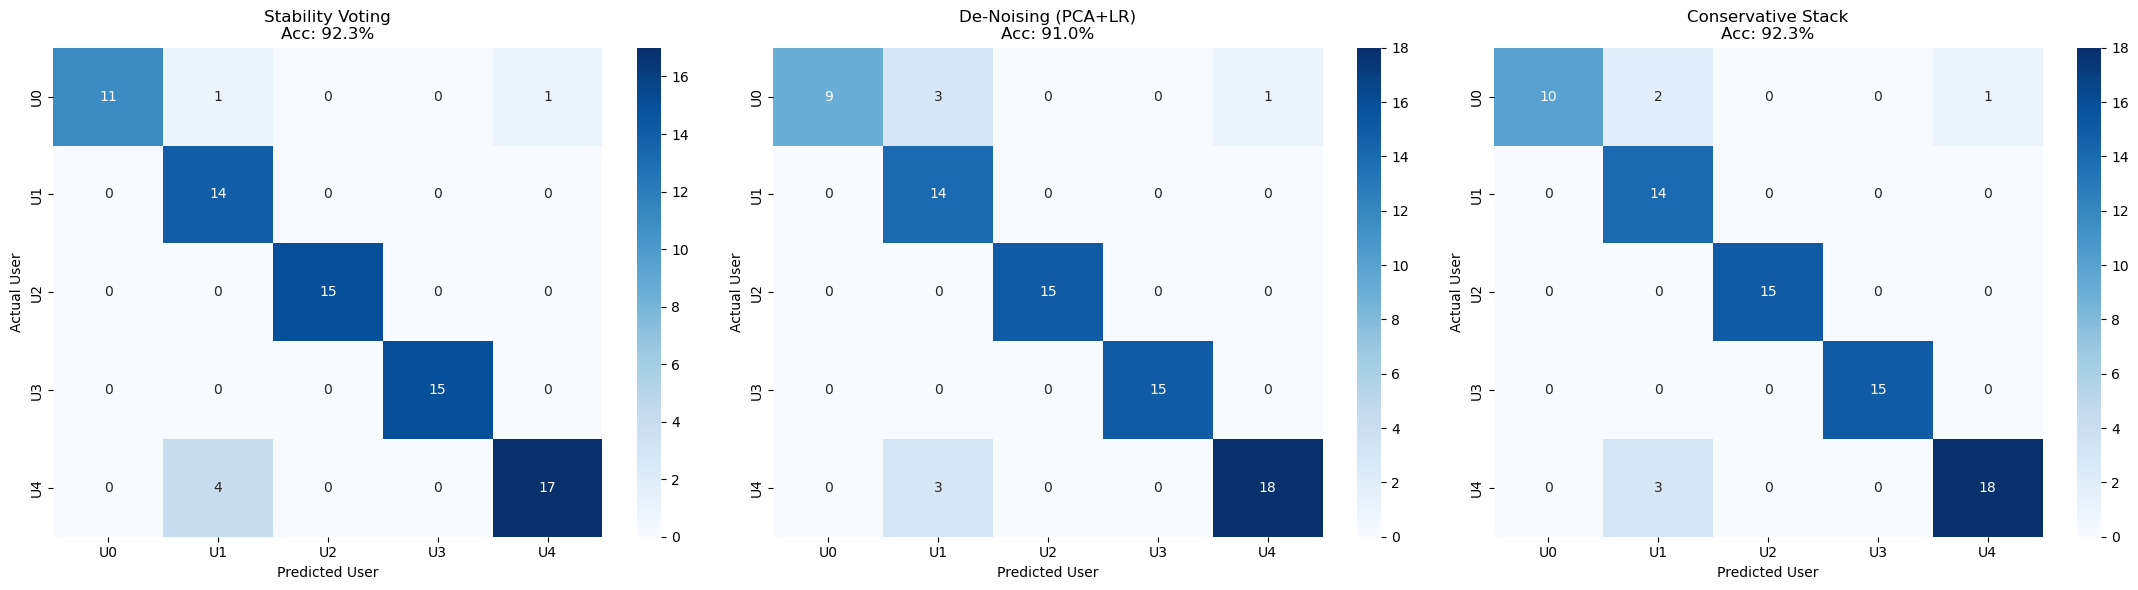


--- Summary Performance Comparison ---
Scenario              60/40   90/10
Model                              
Conservative Stack   92.31%  95.00%
De-Noising (PCA+LR)  91.03%  95.00%
Stability Voting     92.31%  95.00%


C:\Users\blain\AppData\Local\Temp\ipykernel_36232\3156845673.py:101: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_df.applymap(lambda x: f"{x*100:.2f}%"))


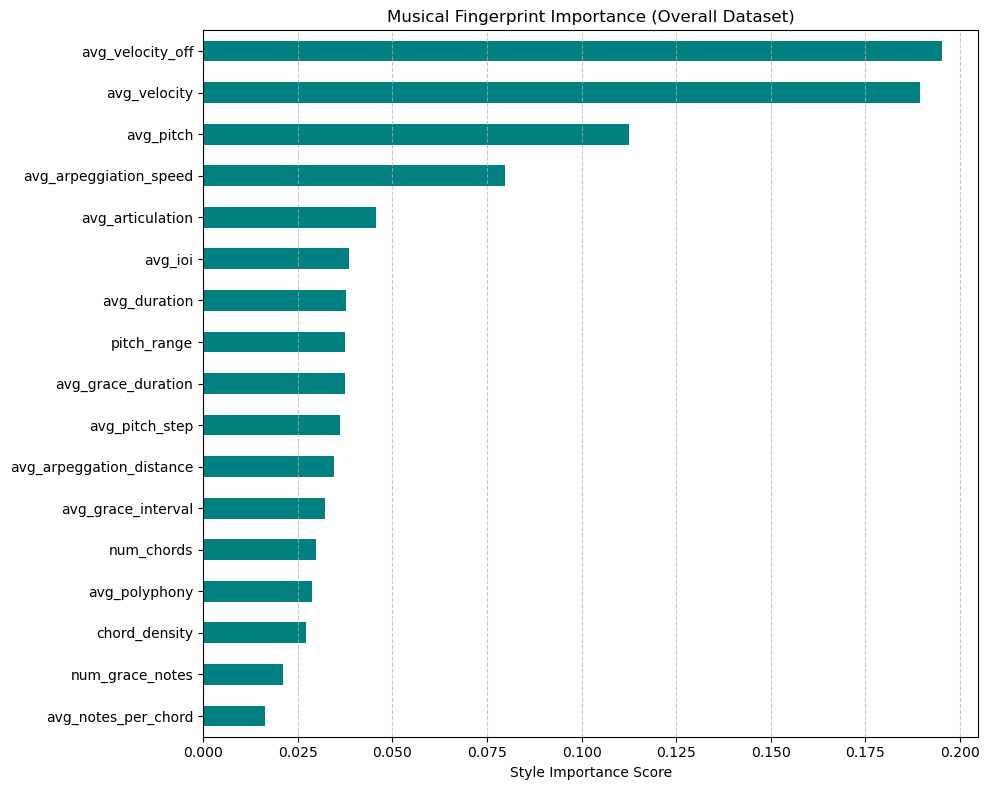

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model & Utility imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD DATA
# Ensure the updated dataset with Users 4 and 5 is loaded
df = pd.read_csv('stacked_dataset.csv')
df = df.fillna(0) # Handle potential NaNs from merged recordings

# 2. PREPARE FEATURES (X) AND TARGET (y)
X = df.drop(columns=['userID', 'window_id', 'time_ms'])
y = df['userID']

# 3. DEFINE THE 3 COMPOUND MODELS
def get_compound_models():
    # Model A: Stability Voting (ET + kNN + LogReg)
    stability_voting = VotingClassifier(
        estimators=[
            ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
            ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))),
            ('lr', make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)))
        ],
        voting='soft'
    )
    
    # Model B: De-Noising Pipeline (PCA + LogReg)
    denoising_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.90)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ])
    
    # Model C: Conservative Stack (RF + kNN -> LogReg)
    conservative_stack = StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5
    )
    
    return {
        "Stability Voting": stability_voting,
        "De-Noising (PCA+LR)": denoising_pipeline,
        "Conservative Stack": conservative_stack
    }

# 4. RUN SPLIT SCENARIOS
# Scenarios: 90/10 (0.10 test) and 60/40 (0.40 test)
scenarios = {"90/10": 0.10, "60/40": 0.40}
all_results = []

for scenario_name, test_size in scenarios.items():
    print(f"\n{'='*50}")
    print(f" SCENARIO: {scenario_name} TRAIN/TEST SPLIT")
    print(f"{'='*50}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    models = get_compound_models()
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    for i, (name, model) in enumerate(models.items()):
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        all_results.append({"Scenario": scenario_name, "Model": name, "Accuracy": acc})
        
        # Plot Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=[f'U{j}' for j in np.unique(y)],
                    yticklabels=[f'U{j}' for j in np.unique(y)])
        axes[i].set_title(f'{name}\nAcc: {acc*100:.1f}%')
        axes[i].set_ylabel('Actual User')
        axes[i].set_xlabel('Predicted User')

    plt.tight_layout()
    plt.show()

# 5. FINAL COMPARISON TABLE
print("\n--- Summary Performance Comparison ---")
comparison_df = pd.DataFrame(all_results)
pivot_df = comparison_df.pivot(index='Model', columns='Scenario', values='Accuracy')
print(pivot_df.applymap(lambda x: f"{x*100:.2f}%"))

# 6. FEATURE IMPORTANCE (Global Analysis)
et_check = ExtraTreesClassifier(n_estimators=100, random_state=42).fit(X, y)
importances = pd.Series(et_check.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='teal')
plt.title('Musical Fingerprint Importance (Overall Dataset)')
plt.xlabel('Style Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# --- INFERENCE BLOCK: PREDICT NEW USER ---
import pandas as pd
import numpy as np

def predict_new_recording(file_path):
    # 1. Load the new user's data
    try:
        new_data = pd.read_csv(file_path)
    except FileNotFoundError:
        return f"Error: The file '{file_path}' was not found."
    
    # 2. Preprocess: Fill zeros and drop metadata
    # We use .get() or errors='ignore' to ensure it doesn't crash if columns are missing
    X_new = new_data.drop(columns=['window_id', 'time_ms'], errors='ignore')
    X_new = X_new.fillna(0)
    
    # CRITICAL: Ensure column order matches the original training data (X)
    # This assumes 'X' from your training cell is still in memory
    try:
        X_new = X_new[X.columns]
    except NameError:
        return "Error: The variable 'X' (training features) is not defined. Please run your training cells first."

    print(f"\nAnalyzing Recording: {file_path}")
    print(f"Windows detected: {len(X_new)}")
    print("-" * 30)

    inference_results = []

    # 'models' must be the dictionary defined in your training code
    for name, model in models.items():
        # Calculate probabilities for every window in the file
        probs = model.predict_proba(X_new)
        
        # Calculate the mean probability across the whole session
        mean_probs = np.mean(probs, axis=0)
        
        # Identify the user with the highest average probability
        best_index = np.argmax(mean_probs)
        predicted_user = model.classes_[best_index]
        confidence = mean_probs[best_index] * 100
        
        inference_results.append({
            "Model": name,
            "Predicted User": f"User {predicted_user}",
            "Confidence Score": f"{confidence:.2f}%"
        })

    # Display as a clean summary table
    return pd.DataFrame(inference_results)

# --- EXECUTION ---
# Use the filename of the CSV you want to test
report = predict_new_recording('user4Test.csv')
print(report)


Analyzing Recording: AidanTest.csv
Windows detected: 13
------------------------------
                 Model Predicted User Confidence Score
0     Stability Voting         User 4           81.02%
1  De-Noising (PCA+LR)         User 4           79.99%
2   Conservative Stack         User 4           84.42%


In [ ]:
# --- INFERENCE BLOCK: PREDICT NEW USER ---
import pandas as pd
import numpy as np

def predict_new_recording(file_path):
    # 1. Load the new user's data
    try:
        new_data = pd.read_csv(file_path)
    except FileNotFoundError:
        return f"Error: The file '{file_path}' was not found."
    
    # 2. Preprocess: Fill zeros and drop metadata
    # We use .get() or errors='ignore' to ensure it doesn't crash if columns are missing
    X_new = new_data.drop(columns=['window_id', 'time_ms'], errors='ignore')
    X_new = X_new.fillna(0)
    
    # CRITICAL: Ensure column order matches the original training data (X)
    # This assumes 'X' from your training cell is still in memory
    try:
        X_new = X_new[X.columns]
    except NameError:
        return "Error: The variable 'X' (training features) is not defined. Please run your training cells first."

    print(f"\nAnalyzing Recording: {file_path}")
    print(f"Windows detected: {len(X_new)}")
    print("-" * 30)

    inference_results = []

    # 'models' must be the dictionary defined in your training code
    for name, model in models.items():
        # Calculate probabilities for every window in the file
        probs = model.predict_proba(X_new)
        
        # Calculate the mean probability across the whole session
        mean_probs = np.mean(probs, axis=0)
        
        # Identify the user with the highest average probability
        best_index = np.argmax(mean_probs)
        predicted_user = model.classes_[best_index]
        confidence = mean_probs[best_index] * 100
        
        inference_results.append({
            "Model": name,
            "Predicted User": f"User {predicted_user}",
            "Confidence Score": f"{confidence:.2f}%"
        })

    # Display as a clean summary table
    return pd.DataFrame(inference_results)

# --- EXECUTION ---
# Use the filename of the CSV you want to test
report = predict_new_recording('user0Test.csv')
print(report)


Analyzing Recording: modified_features0.csv
Windows detected: 33
------------------------------
                 Model Predicted User Confidence Score
0     Stability Voting         User 0           51.64%
1  De-Noising (PCA+LR)         User 0           49.06%
2   Conservative Stack         User 0           54.43%
